# I want to plot the raw data from both experiments against each other

In [19]:
from metamers.eeg.ssvep2python import load_ssvep_npz
from metamers.eeg.ssvep_plotting import *
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

data = load_ssvep_npz("/home/zevaz/projects/metamers/eeg/ssveps/MET000b.npz")
ssvep = data["run_map"]
ssvep_mean = ssvep.mean(axis=2)

ssvep_vector = ssvep_mean.ravel().reshape(-1, 1)
data["red_array"]

array([   0.        ,  355.55555556,  711.11111111, 1066.66666667,
       1422.22222222, 1777.77777778, 2133.33333333, 2488.88888889,
       2844.44444444, 3200.        ])

In [ ]:

expFolder = "data3_grid_10Jun26"
base = Path.home() / "projects" / "metamers" / "hueSensor" / expFolder

def summarize_stims(path):
    df = pd.read_csv(path, sep="\t", header=0)

    # 1. Keep exp runs
    df = df[df["Stim"] < 999]

    # 2. Keep only activation periods
    df = df[df["Trig"] == 1]

    # 3. Work only with Stim > 1
    df = df[df["Stim"] >= 1]

    # Prepare output rows
    rows = []

    # 4. Process each Stim separately
    for stim, block in df.groupby("Stim"):

        # Trim first 3 and last 3 samples
        if len(block) < 7:
            # Not enough samples to trim → skip
            continue

        trimmed = block.iloc[3:-3].reset_index(drop=True)

        # Compute means
        meanR = trimmed["HueR"].mean()
        meanG = trimmed["HueG"].mean()
        meanB = trimmed["HueB"].mean()

        # Extract 15th sample (index 14)
        if len(trimmed) > 14:
            red15 = trimmed["Red"].iloc[14]
            green15 = trimmed["Green"].iloc[14]
        else:
            red15 = None
            green15 = None

        rows.append({
            "Stim": stim,
            "meanHueR": meanR,
            "meanHueG": meanG,
            "meanHueB": meanB,
            "reds": red15,
            "greens": green15
        })
    return pd.DataFrame(rows)
fileNam = base / "flash_NF.txt"
df_hue = summarize_stims(fileNam)
print(df_hue)


    Stim     meanHueR     meanHueG     meanHueB  reds  greens
0      1  1797.794872   992.205128   610.897436     0       0
1      2  1814.230769  1089.743590   648.000000     0     222
2      3  1971.769231   997.794872   629.871795   355       0
3      4  1829.948718  1274.589744   725.538462     0     444
4      5  1982.076923  1095.615385   666.358974   355     222
..   ...          ...          ...          ...   ...     ...
95    96  4282.410256  2521.923077  1465.153846  2844    1777
96    97  4645.897436  2349.974359  1422.794872  3200    1555
97    98  4292.948718  2701.358974  1538.461538  2844    2000
98    99  4618.769231  2514.820513  1488.974359  3200    1777
99   100  4607.923077  2682.282051  1556.051282  3200    2000

[100 rows x 6 columns]


In [58]:

def attach_ssvep_to_hue(df_hue, mean_ssvep, red_axis, green_axis):
    """
    df_hue: dataframe with columns 'reds', 'greens'
    mean_ssvep: 10x10 array indexed as [redIndex, greenIndex]
    red_axis: 1D array of length 10 (data['Reds'])
    green_axis: 1D array of length 10 (data['Greens'])
    """

    ssvep_vals = []

    for _, row in df_hue.iterrows():
        r = row["reds"]
        g = row["greens"]

        # find closest red index
        i_red = np.argmin(np.abs(red_axis - r))

        # find closest green index
        j_green = np.argmin(np.abs(green_axis - g))

        # grab ssvep value at that grid point
        #val = mean_ssvep[i_red, j_green]
        val = mean_ssvep[j_green, i_red]
        ssvep_vals.append(val)

    df_hue_ssvep = df_hue.copy()
    df_hue_ssvep["mean_ssvep"] = ssvep_vals

    return df_hue_ssvep


def minmax_scale(x):
    x = np.asarray(x, dtype=float)
    xmin = np.min(x)
    xmax = np.max(x)
    if xmax == xmin:
        return np.zeros_like(x)   # avoid division by zero
    return (x - xmin) / (xmax - xmin)
    
df_hue_ssvep= attach_ssvep_to_hue(df_hue,ssvep_mean, data["red_array"], data["green_array"])
print(df_hue_ssvep)

    Stim     meanHueR     meanHueG     meanHueB  reds  greens  mean_ssvep
0      1  1797.794872   992.205128   610.897436     0       0    1.335249
1      2  1814.230769  1089.743590   648.000000     0     222    1.318100
2      3  1971.769231   997.794872   629.871795   355       0    1.598758
3      4  1829.948718  1274.589744   725.538462     0     444    1.855611
4      5  1982.076923  1095.615385   666.358974   355     222    1.606183
..   ...          ...          ...          ...   ...     ...         ...
95    96  4282.410256  2521.923077  1465.153846  2844    1777    1.470614
96    97  4645.897436  2349.974359  1422.794872  3200    1555    1.471013
97    98  4292.948718  2701.358974  1538.461538  2844    2000    1.430088
98    99  4618.769231  2514.820513  1488.974359  3200    1777    1.526356
99   100  4607.923077  2682.282051  1556.051282  3200    2000    1.556890

[100 rows x 7 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

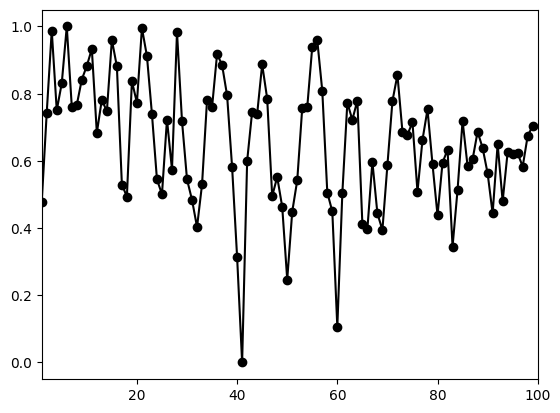

In [66]:
mssvep  = df_hue_ssvep["mean_ssvep"]

plt.plot(minmax_scale(mssvep), marker = 'o', color="black")
plt.xlim(1,100)
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

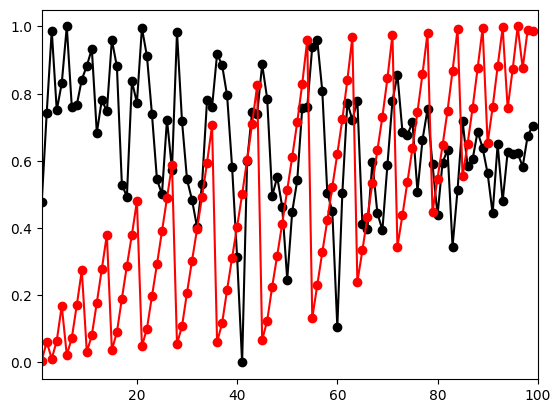

In [68]:


mssvep  = df_hue_ssvep["mean_ssvep"]
plt.plot(minmax_scale(mssvep), marker = 'o', color="black")
plt.plot(minmax_scale(df_hue_ssvep["meanHueR"]), marker = 'o', color="red")
plt.xlim(1,100)
plt.show
# print(min(mssvep), idx, df_hue_ssvep["reds"][idx], df_hue_ssvep["greens"][idx])


<function matplotlib.pyplot.show(close=None, block=None)>

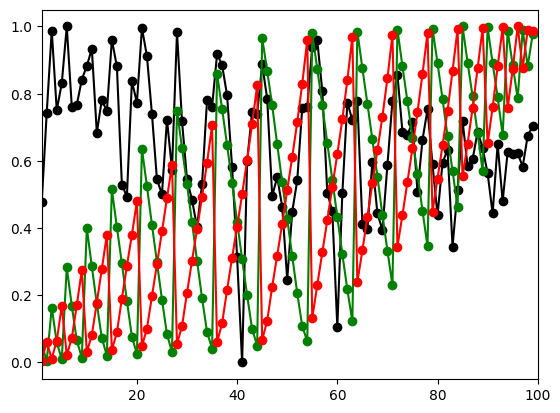

In [72]:

plt.plot(minmax_scale(mssvep), marker = 'o', color="black")
plt.plot(minmax_scale(df_hue_ssvep["meanHueG"]), marker = 'o', color="green")
plt.plot(minmax_scale(df_hue_ssvep["meanHueR"]), marker = 'o', color="red")

plt.xlim(1,100)
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

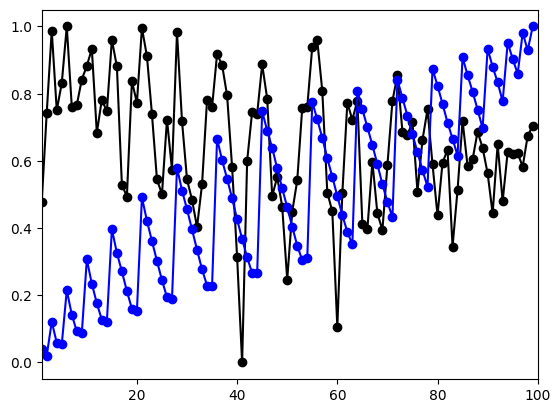

In [64]:
plt.plot(minmax_scale(mssvep), marker = 'o', color="black")
plt.plot(minmax_scale(df_hue_ssvep["meanHueB"]), marker = 'o', color="blue")
plt.xlim(1,100)
plt.show
